# Árboles de Decisión en Machine Learning: *Decision Tree*

En este notebook vamos a construir, paso a paso, un **árbol de decisión para clasificación** usando el conjunto de datos **Iris**.

Recordatorio rápido:

- Un árbol de decisión es un modelo de **aprendizaje supervisado**: aprende a partir de ejemplos que ya tienen la respuesta correcta (la especie de la flor).
- Toma decisiones haciendo una serie de **preguntas de sí o no** sobre los datos.
- Nadie le da las preguntas: el modelo **las descubre** a partir de los datos.

> **Antes de empezar:** si es la primera vez que corres el notebook y te aparece un error de `ModuleNotFoundError`, quita el `#` de la siguiente celda y ejecútala una sola vez para instalar las librerías.

In [1]:
# Instala las librerías necesarias (solo hace falta una vez).
# Quita el "#" de la línea de abajo para ejecutarla:
# %pip install scikit-learn pandas matplotlib

## 1. Importar librerías

- **numpy**: operaciones con números y arreglos.
- **pandas**: manejar tablas de datos (*DataFrames*).
- **matplotlib**: hacer gráficas.
- **scikit-learn** (`sklearn`): la librería de Machine Learning. De ahí tomamos los datos de Iris, el árbol de decisión y las herramientas para evaluarlo.

In [21]:
import numpy as np                     # cálculos numéricos
import pandas as pd                    # tablas de datos
import matplotlib.pyplot as plt        # gráficas
from matplotlib.colors import ListedColormap  # para elegir nuestros propios colores

from sklearn.datasets import load_iris                    # el conjunto de datos Iris
from sklearn.model_selection import train_test_split      # para separar entrenamiento y prueba
from sklearn.tree import DecisionTreeClassifier           # el árbol de decisión (clasificación)
from sklearn.tree import plot_tree, export_text           # para dibujar el árbol y verlo como texto
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay  # para evaluar el modelo

# Colores lilas uno por especie
colores = ["#E8DDF3", "#B58FD6", "#6B3FA0"]

## 2. Cargar y conocer los datos

El conjunto **Iris** tiene **150 flores** de 3 especies: *Setosa*, *Versicolor* y *Virginica* (50 de cada una).
De cada flor se midieron 4 cosas (en cm):

| Variable | Significado |
|---|---|
| largo sépalo | largo del sépalo |
| ancho sépalo | ancho del sépalo |
| largo pétalo | largo del pétalo |
| ancho pétalo | ancho del pétalo |

Vamos a guardarlo en una tabla con los nombres en español.

In [3]:
# Cargamos el conjunto de datos que ya viene incluido en scikit-learn
iris = load_iris()

# Nombres de las columnas y de las especies, en español
nombres_variables = ["largo sépalo", "ancho sépalo", "largo pétalo", "ancho pétalo"]
nombres_especies = ["Setosa", "Versicolor", "Virginica"]

# Creamos una tabla (DataFrame) con las 4 medidas de cada flor
datos = pd.DataFrame(iris.data, columns=nombres_variables)

# Agregamos la especie: iris.target trae números (0, 1, 2) y los cambiamos por su nombre
datos["especie"] = [nombres_especies[i] for i in iris.target]

# Mostramos las primeras 5 filas de la tabla
datos.head()

,largo sépalo,ancho sépalo,largo pétalo,ancho pétalo,especie
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [4]:
# ¿Cuántas flores hay de cada especie?
datos["especie"].value_counts()

especie
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64

Hay exactamente 50 flores de cada especie: el conjunto está **balanceado**.

Veamos cómo se reparten las flores según las medidas de su pétalo:

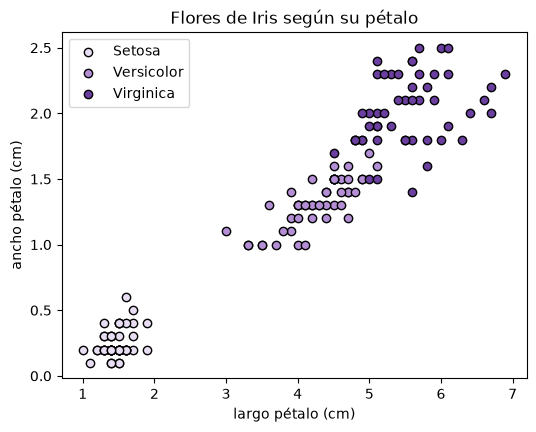

In [5]:
# Gráfica de dispersión: cada punto es una flor, el color indica su especie
plt.figure(figsize=(6, 4.5))
for i, especie in enumerate(nombres_especies):
    # Nos quedamos solo con las flores de esta especie
    grupo = datos[datos["especie"] == especie]
    plt.scatter(grupo["largo pétalo"], grupo["ancho pétalo"],
                color=colores[i], edgecolor="black", label=especie)

plt.xlabel("largo pétalo (cm)")
plt.ylabel("ancho pétalo (cm)")
plt.title("Flores de Iris según su pétalo")
plt.legend()
plt.show()

Se ve a simple vista que **Setosa** (pétalos pequeños) está muy separada de las otras dos. *Versicolor* y *Virginica* están más cerca, pero también se distinguen bastante.

## 3. Elegir las variables

En aprendizaje supervisado separamos:

- **X** → las **variables de entrada** (lo que el modelo puede "ver").
- **y** → la **variable objetivo** (la respuesta que queremos predecir: la especie).

Para que sea sencillo, y para poder dibujar el árbol como un mapa en 2D, usamos **solo dos variables**.

In [6]:
# Variables de entrada: solo largo y ancho del pétalo
variables = ["largo pétalo", "ancho pétalo"]
X = datos[variables]

# Variable objetivo: la especie de cada flor
y = datos["especie"]

# Revisamos el tamaño: 150 flores (filas) y 2 variables (columnas)
print("Tamaño de X:", X.shape)
print("Tamaño de y:", y.shape)

Tamaño de X: (150, 2)
Tamaño de y: (150,)


## 4. Separar datos de entrenamiento y de prueba

Si evaluamos al modelo con las mismas flores con las que aprendió, sería como presentar un examen con las respuestas en la mano. Por eso dividimos los datos:

- **Entrenamiento (70 %)**: con estas flores el árbol aprende sus preguntas.
- **Prueba (30 %)**: flores que el árbol **nunca ha visto**; sirven para medir qué tan bien funciona con datos nuevos.

`stratify=y` hace que en ambos grupos haya la misma proporción de cada especie, y `random_state=14` es una **semilla**: fija qué flores caen en cada grupo, para que la división sea siempre la misma cada vez que corremos el notebook.

In [7]:
X_entrena, X_prueba, y_entrena, y_prueba = train_test_split(
    X, y,
    test_size=0.3,      # 30 % de las flores se guardan para la prueba
    stratify=y,         # misma proporción de especies en ambos grupos
    random_state=14,    # semilla: fija qué flores van a cada grupo (resultado reproducible)
)

print("Flores para entrenar:", len(X_entrena))
print("Flores para probar:  ", len(X_prueba))

Flores para entrenar: 105
Flores para probar:   45


## 5. ¿Qué tan "revuelto" está un grupo? El índice de Gini a mano

Antes de dejar que `scikit-learn` haga todo, calculemos nosotros mismos lo que el árbol usa para elegir sus preguntas.

La **impureza** de un grupo se mide con el **índice de Gini**:

$$G = 1 - \sum_k p_k^2$$

donde $p_k$ es la proporción de la clase $k$ en el grupo.

- Grupo **puro** (todas las flores de la misma especie) ⇒ $G = 0$.
- Grupo más mezclado ⇒ $G$ más grande.

In [8]:
def gini(etiquetas):
    # Proporción de cada clase dentro del grupo (p_k)
    proporciones = etiquetas.value_counts(normalize=True)
    # Fórmula del índice de Gini: G = 1 - suma(p_k^2)
    return 1 - np.sum(proporciones ** 2)

# Gini de TODAS las flores (50 de cada especie): p_k = 1/3 para las tres
print("Gini de todos los datos:", round(gini(y), 3))

Gini de todos los datos: 0.667


Con las tres especies igual de mezcladas, $G = 1 - 3\cdot(1/3)^2 \approx 0.667$, que es lo máximo posible con 3 clases.

Ahora probamos la pregunta de la presentación: **¿largo pétalo ≤ 2.45?** Esta pregunta corta los datos en dos grupos. Calculamos el Gini de cada uno:

In [9]:
# Hacemos la pregunta a cada flor: True = "sí", False = "no"
respuesta = datos["largo pétalo"] <= 2.45

# Separamos las especies en dos grupos según la respuesta
grupo_si = y[respuesta]     # flores que respondieron "sí"
grupo_no = y[~respuesta]    # flores que respondieron "no" (~ significa "lo contrario")

print("Grupo 'sí':", len(grupo_si), "flores →", dict(grupo_si.value_counts()))
print("Grupo 'no':", len(grupo_no), "flores →", dict(grupo_no.value_counts()))
print()
print("Gini grupo 'sí':", round(gini(grupo_si), 3))
print("Gini grupo 'no':", round(gini(grupo_no), 3))

Grupo 'sí': 50 flores → {'Setosa': np.int64(50)}
Grupo 'no': 100 flores → {'Versicolor': np.int64(50), 'Virginica': np.int64(50)}

Gini grupo 'sí': 0.0
Gini grupo 'no': 0.5


¡El grupo "sí" quedó **puro** ($G = 0$): solo hay Setosas! El grupo "no" tiene Versicolor y Virginica mitad y mitad ($G = 0.5$).

### ¿Fue una buena pregunta? La ganancia

Comparamos el desorden **antes** y **después** del corte:

$$\text{Ganancia} = \text{impureza antes} - \text{impureza después}$$

La impureza "después" es el **promedio de los dos grupos, ponderado por su tamaño** (un grupo con más flores pesa más).

In [10]:
n_total = len(y)  # número total de flores

# Impureza antes del corte
gini_antes = gini(y)

# Impureza después: promedio ponderado por el tamaño de cada grupo
gini_despues = (len(grupo_si) / n_total) * gini(grupo_si) + (len(grupo_no) / n_total) * gini(grupo_no)

# Ganancia = antes - después
ganancia = gini_antes - gini_despues

print("Impureza antes:  ", round(gini_antes, 3))
print("Impureza después:", round(gini_despues, 3))
print("Ganancia:        ", round(ganancia, 3))

Impureza antes:   0.667
Impureza después: 0.333
Ganancia:         0.333


La pregunta redujo el desorden de 0.667 a 0.333: una ganancia de **0.333**.

El árbol hace exactamente esto, pero con **muchas** preguntas posibles (todas las variables y muchos valores de corte), y se queda con la de **mayor ganancia**. Luego repite lo mismo dentro de cada grupo nuevo. Es una estrategia **codiciosa** (*greedy*): en cada paso elige lo mejor en ese momento.

## 6. Entrenar el árbol

Ahora dejamos que `scikit-learn` construya el árbol. Le damos tres indicaciones:

- `criterion="gini"`: usar el índice de Gini para medir la impureza (como hicimos arriba).
- `max_depth=2`: el árbol puede hacer como máximo **2 niveles de preguntas**. Esto es **limitar el crecimiento** para evitar que memorice los datos.
- `random_state=42`: para que el resultado sea siempre el mismo.

El método `.fit()` es donde el modelo **aprende** a partir de los datos de entrenamiento.

In [11]:
# Creamos el árbol (todavía no sabe nada)
arbol = DecisionTreeClassifier(criterion="gini", max_depth=2, random_state=42)

# Lo entrenamos: aquí descubre las mejores preguntas a partir de los datos
arbol.fit(X_entrena, y_entrena)

print("¡Árbol entrenado!")
print("Profundidad:", arbol.get_depth())
print("Número de hojas:", arbol.get_n_leaves())

¡Árbol entrenado!
Profundidad: 2
Número de hojas: 3


## 7. El árbol como diagrama

La forma más intuitiva de ver el árbol: cada caja es una **pregunta** y cada hoja da una **especie**.

En cada caja aparece:

- la **pregunta** (solo en los nodos que no son hojas),
- `gini`: la impureza del grupo que llegó ahí,
- `samples`: cuántas flores llegaron a ese nodo,
- `value`: cuántas flores hay de cada especie,
- `class`: la especie más común (la predicción si el recorrido terminara ahí).

Las ramas hacia la **izquierda** son la respuesta **"sí"** (*True*) y hacia la **derecha** **"no"** (*False*).

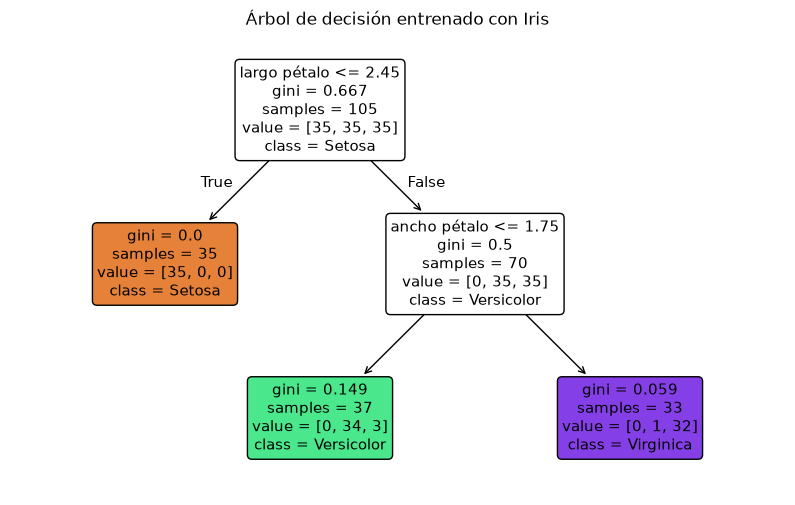

In [12]:
plt.figure(figsize=(10, 6))
plot_tree(
    arbol,
    feature_names=variables,             # nombres de las variables en las preguntas
    class_names=arbol.classes_,          # nombres de las especies en las hojas
    filled=True,                         # colorea cada caja según la especie dominante
    rounded=True,                        # esquinas redondeadas
    fontsize=11,
)
plt.title("Árbol de decisión entrenado con Iris")
plt.show()

También podemos ver el árbol como **texto**, que se lee como una lista de reglas "si… entonces…":

In [13]:
# export_text escribe el árbol como reglas de texto
print(export_text(arbol, feature_names=variables))

|--- largo pétalo <= 2.45
|   |--- class: Setosa
|--- largo pétalo >  2.45
|   |--- ancho pétalo <= 1.75
|   |   |--- class: Versicolor
|   |--- ancho pétalo >  1.75
|   |   |--- class: Virginica



El árbol encontró por sí solo las mismas preguntas de la presentación:

1. **¿largo pétalo ≤ 2.45?** → si la respuesta es "sí", es **Setosa**.
2. Si no, **¿ancho pétalo ≤ 1.75?** → "sí" es **Versicolor**, "no" es **Virginica**.

Nadie le dijo qué preguntar: las descubrió buscando los cortes con mayor ganancia.

> **Nota:** los valores de corte dependen de qué flores se usaron para entrenar. Si cambias la semilla `random_state` de la sección 4, el segundo corte puede moverse un poco (por ejemplo, a 1.55 o 1.65), porque el árbol solo ve el 70 % de las flores.

## 8. Hacer predicciones

Un dato nuevo entra por la raíz y **baja respondiendo cada pregunta** hasta llegar a una hoja. A este recorrido se le llama *inference path*.

Probemos con el ejemplo de la presentación: una flor con pétalo de **1.4 cm** de largo (y 0.2 cm de ancho), y con otras dos flores inventadas.

In [14]:
# Tres flores nuevas que el árbol nunca ha visto: [largo pétalo, ancho pétalo]
flores_nuevas = pd.DataFrame(
    [[1.4, 0.2],    # pétalo pequeño
     [4.5, 1.4],    # pétalo mediano
     [5.8, 2.2]],   # pétalo grande
    columns=variables,
)

# .predict() recorre el árbol para cada flor y devuelve la especie de la hoja
predicciones = arbol.predict(flores_nuevas)

# Mostramos el resultado de cada flor
for i in range(len(flores_nuevas)):
    largo, ancho = flores_nuevas.iloc[i]
    print(f"Flor con pétalo de {largo} x {ancho} cm → {predicciones[i]}")

Flor con pétalo de 1.4 x 0.2 cm → Setosa
Flor con pétalo de 4.5 x 1.4 cm → Versicolor
Flor con pétalo de 5.8 x 2.2 cm → Virginica


Sigamos el recorrido de la primera flor (pétalo de 1.4 cm), igual que en la diapositiva:

- ¿1.4 ≤ 2.45? ⇒ **sí** ⇒ llegamos a una hoja ⇒ Predicción: **Setosa**.

El siguiente código imprime el recorrido de cada flor de forma automática:

In [15]:
# Información interna del árbol
variable_de_nodo = arbol.tree_.feature    # qué variable pregunta cada nodo
umbral_de_nodo = arbol.tree_.threshold    # el valor de corte de cada nodo

# decision_path nos dice por qué nodos pasó cada flor
caminos = arbol.decision_path(flores_nuevas)
hojas = arbol.apply(flores_nuevas)        # la hoja final de cada flor

for i in range(len(flores_nuevas)):
    print(f"Flor {i + 1}: {list(flores_nuevas.iloc[i])}")
    # Nodos visitados por la flor i
    nodos = caminos.indices[caminos.indptr[i]:caminos.indptr[i + 1]]
    for nodo in nodos:
        if nodo == hojas[i]:
            # Llegamos a la hoja: ya no hay preguntas
            print(f"   → Hoja: {predicciones[i]}")
        else:
            nombre = variables[variable_de_nodo[nodo]]
            valor = flores_nuevas.iloc[i][nombre]
            umbral = umbral_de_nodo[nodo]
            respuesta = "sí" if valor <= umbral else "no"
            print(f"   ¿{nombre} ≤ {umbral:.2f}?  ({valor} ≤ {umbral:.2f}) ⇒ {respuesta}")
    print()

Flor 1: [1.4, 0.2]
   ¿largo pétalo ≤ 2.45?  (1.4 ≤ 2.45) ⇒ sí
   → Hoja: Setosa

Flor 2: [4.5, 1.4]
   ¿largo pétalo ≤ 2.45?  (4.5 ≤ 2.45) ⇒ no
   ¿ancho pétalo ≤ 1.75?  (1.4 ≤ 1.75) ⇒ sí
   → Hoja: Versicolor

Flor 3: [5.8, 2.2]
   ¿largo pétalo ≤ 2.45?  (5.8 ≤ 2.45) ⇒ no
   ¿ancho pétalo ≤ 1.75?  (2.2 ≤ 1.75) ⇒ no
   → Hoja: Virginica



Además de la especie, el árbol puede decir **qué tan seguro** está. `predict_proba` devuelve la proporción de cada especie entre las flores de entrenamiento que cayeron en la misma hoja:

In [16]:
# Probabilidad de cada especie para cada flor nueva
probabilidades = pd.DataFrame(arbol.predict_proba(flores_nuevas),
                              columns=arbol.classes_).round(2)
probabilidades

,Setosa,Versicolor,Virginica
0,1.0,0.00,0.00
1,0.0,0.92,0.08
2,0.0,0.03,0.97


## 9. Evaluar el modelo

Ahora usamos las flores de **prueba** (que el árbol nunca vio) para medir qué tan bien funciona.

- **Exactitud** (*accuracy*): porcentaje de flores clasificadas correctamente.
- **Matriz de confusión**: tabla que compara la especie real (filas) con la predicha (columnas). Los números en la diagonal son los aciertos; fuera de ella, los errores.

In [17]:
# Predecimos la especie de las flores de prueba
y_predicha = arbol.predict(X_prueba)

# Comparamos con la especie real
exactitud = accuracy_score(y_prueba, y_predicha)
print(f"Exactitud en prueba: {exactitud:.2%}")

Exactitud en prueba: 95.56%


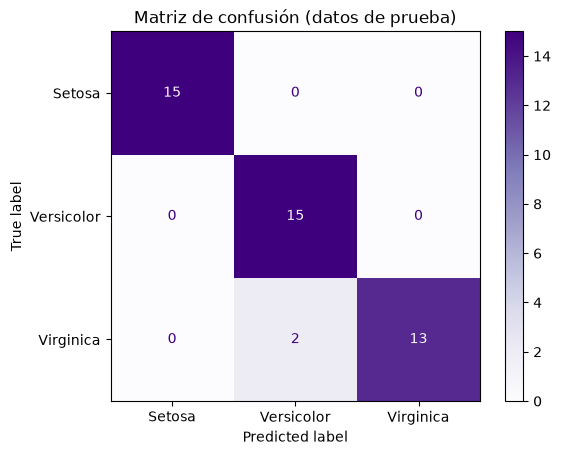

In [18]:
# Matriz de confusión: especie real vs. especie predicha
ConfusionMatrixDisplay.from_predictions(y_prueba, y_predicha, cmap="Purples")
plt.title("Matriz de confusión (datos de prueba)")
plt.show()

Casi todas las flores quedan en la diagonal. Setosa nunca se confunde (está muy separada); los pocos errores ocurren entre **Versicolor** y **Virginica**, que son las especies más parecidas.

## 10. El árbol como mapa

Con dos variables podemos dibujar lo que hace el árbol sobre el plano:

- Cada pregunta es una **línea recta paralela a un eje** (por ejemplo, "largo pétalo = 2.45" es una línea vertical).
- El plano queda dividido en **rectángulos**.
- Cada rectángulo es **una hoja** del árbol.

Para dibujarlo, creamos una malla de muchísimos puntos, le pedimos al árbol que prediga la especie en cada uno y pintamos cada región con su color.

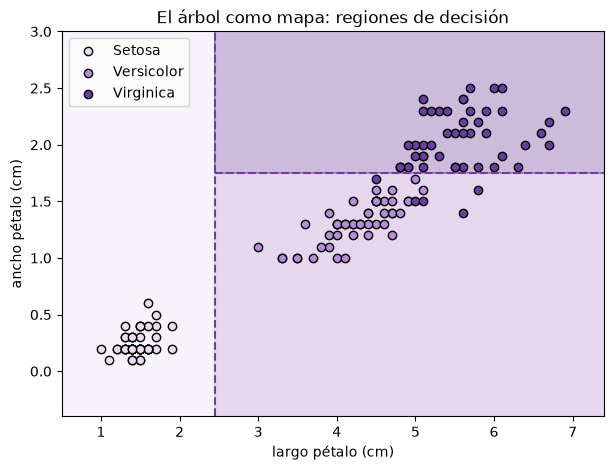

In [19]:
# 1) Creamos una malla de puntos que cubre todo el rango de los datos
x_min, x_max = X["largo pétalo"].min() - 0.5, X["largo pétalo"].max() + 0.5
y_min, y_max = X["ancho pétalo"].min() - 0.5, X["ancho pétalo"].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                     np.linspace(y_min, y_max, 400))

# 2) Juntamos los puntos de la malla en una tabla con las mismas columnas que X
malla = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=variables)

# 3) Predecimos la especie en cada punto y la convertimos a número (0, 1, 2) para pintar
especie_malla = arbol.predict(malla)
numero_malla = np.array([nombres_especies.index(e) for e in especie_malla]).reshape(xx.shape)

# 4) Pintamos las regiones del árbol
plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, numero_malla, alpha=0.35, cmap=ListedColormap(colores))

# 5) Encima, dibujamos las flores reales
for i, especie in enumerate(nombres_especies):
    grupo = datos[datos["especie"] == especie]
    plt.scatter(grupo["largo pétalo"], grupo["ancho pétalo"],
                color=colores[i], edgecolor="black", label=especie)

# 6) Marcamos los cortes que encontró el árbol
corte_1 = arbol.tree_.threshold[0]                     # pregunta de la raíz
corte_2 = arbol.tree_.threshold[arbol.tree_.children_right[0]]  # pregunta del nodo de la derecha
plt.axvline(corte_1, color="#6B3FA0", linestyle="--")
plt.hlines(corte_2, corte_1, x_max, color="#6B3FA0", linestyle="--")

plt.xlabel("largo pétalo (cm)")
plt.ylabel("ancho pétalo (cm)")
plt.title("El árbol como mapa: regiones de decisión")
plt.legend()
plt.show()

Las fronteras son **"escalonadas"** (formadas por rectángulos), a diferencia de un modelo lineal, que trazaría líneas diagonales. Cada rectángulo corresponde a una hoja del diagrama de la sección 7.

## 11. Sobreajuste: ¿qué pasa si el árbol crece sin límite?

Si el árbol pregunta sin límite, puede **memorizar** los datos de entrenamiento (incluido su ruido) y fallar con datos nuevos. A esto se le llama **sobreajuste**.

Comparemos árboles de distinta profundidad. Para cada uno medimos la exactitud con los datos de **entrenamiento** y con los de **prueba**:

In [20]:
# Probamos varias profundidades; None = sin límite (crece hasta que todas las hojas son puras)
profundidades = [1, 2, 3, 5, None]
resultados = []

for profundidad in profundidades:
    # Entrenamos un árbol con esa profundidad máxima
    modelo = DecisionTreeClassifier(max_depth=profundidad, random_state=42)
    modelo.fit(X_entrena, y_entrena)

    # Guardamos sus resultados
    resultados.append({
        "max_depth": "sin límite" if profundidad is None else profundidad,
        "profundidad real": modelo.get_depth(),
        "hojas": modelo.get_n_leaves(),
        "exactitud entrenamiento": round(modelo.score(X_entrena, y_entrena), 3),
        "exactitud prueba": round(modelo.score(X_prueba, y_prueba), 3),
    })

pd.DataFrame(resultados)

,max_depth,profundidad real,hojas,exactitud entrenamiento,exactitud prueba
0,1,1,2,0.667,0.667
1,2,2,3,0.962,0.956
2,3,3,5,0.981,0.933
3,5,5,8,0.990,0.933
4,sin límite,6,9,1.000,0.933


Observa:

- Con **1 nivel** el árbol es demasiado simple: solo separa Setosa del resto (le falta aprender).
- Con **2 niveles** (nuestro árbol) acierta alrededor del 96 % tanto en entrenamiento como en prueba.
- Al dejarlo crecer más, la exactitud en **entrenamiento** sube hasta el 100 %: el árbol se "aprende de memoria" las flores que ya vio.
- Pero la exactitud en **prueba** **baja** (de 95.6 % a 93.3 %): el árbol más grande generaliza **peor** con flores nuevas. ¡Eso es el sobreajuste!

Por eso hay que controlar su tamaño: **limitar el crecimiento** (`max_depth`, `min_samples_leaf`) o **podar** el árbol (en scikit-learn, con el parámetro `ccp_alpha`).

## 12. Resumen

> Un árbol de decisión aprende **preguntas de sí o no** que separan los datos en grupos cada vez **más puros**.

- Elige cada pregunta buscando la **mayor ganancia** (la mayor reducción del índice de Gini).
- **Ventaja:** es fácil de entender y de visualizar, como diagrama o como mapa.
- **Cuidado:** hay que controlar su tamaño para que no memorice los datos (sobreajuste).

### Referencias

1. scikit-learn developers, "1.10. Decision Trees," *scikit-learn User Guide*. https://scikit-learn.org/stable/modules/tree.html
2. Google for Developers, "Decision Forests," *Machine Learning course*. https://developers.google.com/machine-learning/decision-forests
3. E. Kavlakoglu, "What is a Decision Tree?," *IBM Think*, 2021. https://www.ibm.com/think/topics/decision-trees
4. G. James, D. Witten, T. Hastie, R. Tibshirani y J. Taylor, *An Introduction to Statistical Learning: with Applications in Python*. Springer, 2023. Cap. 8.
5. scikit-learn developers, "DecisionTreeClassifier," *scikit-learn API Reference*. https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html